In [1]:
import math
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import svds
import xarray as xr

from graphcast.stacked_normalization import normalize
from prototypes.ocn_only.emulator import OcnEvaluator

In [2]:
def load_model_inputs(config, category="validation", nsamples=-1):
    """Loads input data based on the model's configuration.
    Inputs:
        config: the model config
        data_type: training/validation (default=validation)

    Outputs:
        ds (xr.Dataset): the requested dataset 
    """
    
    # Setup
    emulator = OcnEvaluator(config["run"])
    ds_dir = f"{emulator.local_store_path}/{category}"

    # Compute logic
    if os.path.isdir(ds_dir):
        inputs = xr.open_zarr(f"{ds_dir}/inputs.zarr") # (sample, lat, lon, channels)
        return inputs.isel(sample=slice(None, nsamples))
    else:
        raise ValueError(f"{ds_dir} not found. Aborting...")
        sys.exit()

In [3]:
def normalize_inputs(config, inputs):
    """
    Normalizes the inputs using the model config's stored statistics.
    Inputs:
        config (dict): the model config
        inputs (xr.Dataset): the input dataset to normalize
    
    Outputs:
        normalized_inputs (xr.Dataset): normalized inputs
    """
    # Setup
    emulator = OcnEvaluator(config["run"])
    ds_dir = f"{emulator.local_store_path}/stacked-normalization/inputs"

    # mean 
    ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
    ds_stddev = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))
    
    # normalize
    mean = ds_mean["inputs"]
    stddev = ds_stddev["inputs"]
    normalized_inputs = (inputs["inputs"]-mean)/stddev
    masked_normalized_var = normalized_inputs.isel(channels=1).where(1 - inputs["inputs"].isel(channels=6))
    
    return normalized_inputs

In [4]:
def condition_number_iter(X):
    """
    This function computes the condition number for a given dataset 
    using the iterative scipy.sparse.linalg.svds method assuming that 
    the dataset is large and a full SVD decomposition is diffucult. 
    Although the function assumes certain level of sparsity in the 
    dataset, which is not necessarily the case here, I'm not sure if 
    this is a problem. Note that ds must be normalized here.
    
    Inputs:
        X (np.ndarray): zarr input dataset (normalized)
    
    Outputs:
        cond_number (float32): the condition number of ds 
    """
    # Find the largest singular value (sigma_max)
    # We ask for the 1 largest magnitude ('LM') singular value.
    # svds returns u, s, vt. We only need s.
    try:
        _, s_max, _ = svds(X, k=1, which='LM')

        # Find the smallest singular value (sigma_min)
        # We ask for the 1 smallest magnitude ('SM') singular value.
        _, s_min, _ = svds(X, k=1, which='SM')

        # 3. Compute the condition number
        if s_min[0] > 0:
            cond_number = s_max[0] / s_min[0]
            print(f"Shape of data: {X.shape}")
            print(f"Largest singular value (σ_max): {s_max[0]:.2f}")
            print(f"Smallest singular value (σ_min): {s_min[0]:.2f}")
            print(f"Condition number (efficient method): {cond_number:.2f}")
            return cond_number
        else:
            print("Smallest singular value is zero. The matrix is singular.")

    except Exception as e:
        print(f"An error occurred during svds calculation: {e}")
        print("This can happen if k is too close to the matrix dimensions or with convergence issues.")
        
    return

In [5]:
def condition_number_svd(X, compute_uv=False):
    """
    Computes the condition number of a matrix using full SVD.

    Args:
        X (np.ndarray): The input data matrix (n_samples, n_features).
        compute_uv (bool): Whether to compute u and v matrices alongside
                           the singular values.

    Returns:
        U, s, V: All singular values (in s) and the left and right singular 
                 vectors (U and V, respectively).
        condition_number: The condition number of the matrix. Returns 
                          np.inf if the matrix is singular (smallest 
                          singular value is 0).
    """
    # Compute the singular values of the matrix X.
    # We set compute_uv=False because we only need the singular values (s),
    # not the U and Vh matrices, which saves computation.
    if compute_uv:
        U, s, V = np.linalg.svd(X, compute_uv=compute_uv)
    else:
        s = np.linalg.svd(X, compute_uv=compute_uv)

    # Find the largest (s_max) and smallest (s_min) singular values.
    s_max = np.max(s)
    tol = 1e-5
    s_min = np.min(s[s>tol])
    
    print(f"Largest singular value (σ_max): {s_max:.2f}")
    print(f"Smallest singular value (σ_min): {s_min:.2f}")

    # Compute the condition number.
    # Handle the case where s_min is zero to avoid division errors.
    if s_min == 0:
        print("Warning: Smallest singular value is zero. Matrix is singular.")
        return np.inf
    
    condition_number = s_max / s_min

    if compute_uv:
        return U, s, V, condition_number
    else:
        return s, condition_number

## Config and Computation

In [11]:
# ---- Config ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
PLOT_METRIC = "RMSE"

MODELS_CONFIG = [
    {
        "name": "Emulator-6h-1IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R4",
        "expt": "T3M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "6h",
        "duration": "240h",
        "description": "6hour-1ic-coarseTop"
    },
    {
        "name": "Emulator-6h-2IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R2",
        "expt": "T8M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "6h",
        "duration": "240h",
        "description": "6hour-2ic-coarseTop"
    },
    {
        "name": "Emulator-6h-2IC-fineTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R0",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "6h",
        "duration": "240h",
        "description": "6hour-2ic-fineTop"
    },
    {
        "name": "Emulator-24h-1IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-1ic-coarseTop"
    },
    {
        "name": "Emulator-24h-2IC-coarseTop",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R6",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-2ic-coarseTop"
    },
    #{
    #    "name": "Emulator-24h-1IC-fineTop",
    #    "type": "emulator",
    #    "model_type": "ocn-only",
    #    "run": "R1",
    #    "expt": "T1M",
    #    "pred_prefix": "graphufs",
    #    "ref_truth": "replay", 
    #    "timestep": "24h",
    #    "duration": "240h",
    #    "description": "24hour-1ic-fineTop"
    #},
]

## Condition Number

In [12]:
# ---- The Main Computation Block ----
all_cond_number = {}
compute_uv = False
nsamples = 300

# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")

    # Load the model input data
    model_inputs = load_model_inputs(model_config, nsamples=nsamples)
    
    # normalize the inputs
    print("Normalizing Input Dataset ... ")
    standardized_x = normalize_inputs(model_config, model_inputs)
    print("Normalization done!!!")
    
    # compute the condition number
    print("Computing condition number ...")
    da = standardized_x
    data = da.values.reshape((da.sizes["sample"]*da.sizes["lat"]*da.sizes["lon"], 
                              da.sizes["channels"]))
    if compute_uv:
        U, all_cond_number[model_name], V, cond_num = condition_number_svd(data, compute_uv=True)
    else:
        all_cond_number[model_name], cond_num = condition_number_svd(data, compute_uv=False)
        
    #print("last two columns of V:", V[:,-2:])
    print("singular values spectrum:", all_cond_number[model_name])
    print("Condition number = ", cond_num)


Processing Model: Emulator-6h-1IC-coarseTop
Normalizing Input Dataset ... 
Normalization done!!!
Computing condition number ...
Largest singular value (σ_max): 101416.54
Smallest singular value (σ_min): 0.00
singular values spectrum: [1.01416543e+05 1.67822984e+04 1.37698850e+04 1.02670612e+04
 9.00560482e+03 8.48151421e+03 7.92455151e+03 7.13401218e+03
 7.10825745e+03 6.39225996e+03 6.01823164e+03 5.39268023e+03
 4.48804631e+03 4.05424788e+03 3.91161763e+03 3.62228836e+03
 3.36510942e+03 2.88245015e+03 2.77129277e+03 2.51357866e+03
 2.48148911e+03 2.35949107e+03 2.13573894e+03 2.12083966e+03
 1.81271349e+03 1.80791116e+03 1.53007615e+03 1.48316275e+03
 1.44760697e+03 1.37791003e+03 1.20869555e+03 1.20355896e+03
 1.17460265e+03 9.67074110e+02 9.41189015e+02 8.00557990e+02
 6.61493020e+02 6.22270705e+02 5.59378484e+02 5.53653558e+02
 4.99997767e+02 4.90147575e+02 4.27007148e+02 4.23136427e+02
 4.12207418e+02 3.83072738e+02 3.56754534e+02 3.45216244e+02
 3.30152300e+02 3.15237104e+02 2.

In [13]:
def plot_singular_values(sv_dict, save_path=None):
    """
    Visualizes singular values from multiple matrices using a scree plot.

    Args:
        sv_dict (dict): A dictionary where keys are the names (str) and
                        values are lists or arrays of singular values.
        save_path: path to save the figure
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    # Loop through each matrix's singular values in the dictionary
    for name, values in sv_dict.items():
        # Sort values in descending order just in case they aren't already
        sorted_values = sorted(values, reverse=True)
        
        # Create an index for the x-axis (1st, 2nd, 3rd singular value, etc.)
        indices = np.arange(1, len(sorted_values) + 1)
        
        # Plot the singular values for the current matrix
        ax.plot(indices, sorted_values, marker='o', linestyle='-', label=name)

    # --- Formatting the Plot ---
    # Use a log scale on the y-axis to see the decay of small values
    ax.set_yscale('log')
    #ax.set_title('Scree Plot of Singular Values', fontsize=16)
    ax.set_xlabel('Singular Value Index (k)', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude (log scale)', fontsize=12)
    ax.legend(title='Emulators')
    ax.grid(True, which="both", ls="--", alpha=0.6)
    
    # Set the x-axis to have integer ticks
    ax.xaxis.get_major_locator().set_params(integer=True)
    plt.tight_layout()

    # save if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

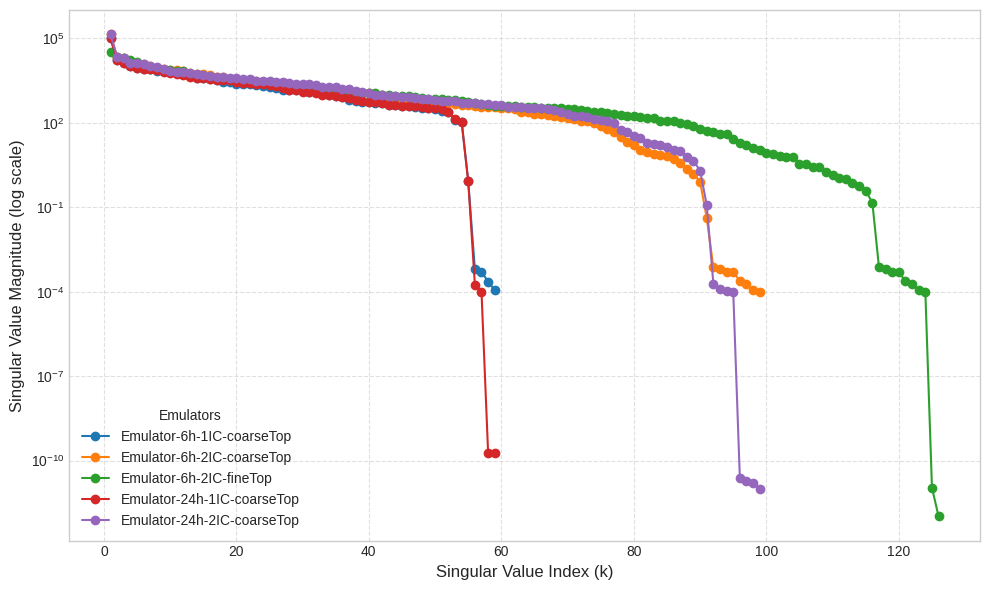

In [14]:
# Plot
save_path = None#"./figures/singular_values_24h_6h_coarseTop_fineTop_1IC_2IC.png"
f = plot_singular_values(all_cond_number, save_path=save_path)